# Markov Chains

## Imports

In [17]:
import numpy as np
import matplotlib.pyplot as plt

## Excersize 1: Markov chain

Write a code to analyze a discrete-time Markov Chain with 5 states ($S = \{0, 1, 2, 3, 4\}$) using 2 methods.

### Method 1: Stochastic Simulation

Simulate the chain for large $n$ steps by randomly picking the next state based on the transition probabilities.

**Tasks:**

* Plot a **frequency of the state occurrences**.
* Calculate the **theoretical steady-state probability** and compare the simulated result with the theoretical value.
* Determine the **final mean observable** and compare the simulated result with the theoretical value.

### Method 2: Matrix Iteration

Use the formula $P_{t+1} = P_t \times T$ or $P_{t+1} = T^T \times P_t$ where $P_t$ is the probability distribution vector at the step $t$.

* Compare the resulting distribution and mean observable with the results from Method 1.
* Why is the final distribution uniform? The transition probabilities are defined as:

$$T(s_i \to s_j) = 1/3 \text{ if } j = i \pm 1 \text{ or } j = i.$$


In [18]:
 # Matrix construction
n_states = 5
T = np.zeros(shape=(n_states, n_states))
for i in range(n_states):
    for j in range(n_states):
        if j==i or abs(j-i) == 1 or abs(j-i) == n_states-1:
            T[i, j] = 1/3

print(f"Transition matrix T:\n {T}")

Transition matrix T:
 [[0.33333333 0.33333333 0.         0.         0.33333333]
 [0.33333333 0.33333333 0.33333333 0.         0.        ]
 [0.         0.33333333 0.33333333 0.33333333 0.        ]
 [0.         0.         0.33333333 0.33333333 0.33333333]
 [0.33333333 0.         0.         0.33333333 0.33333333]]


In [19]:
# Parameters
n_steps = 30000
states = np.arange(n_states)

# --- Theory ---
theoretical_probs = [np.sum(T[0]*0.2) for row in T]
theoretical_mean = np.sum(states * 0.2)

# --- METHOD 1: stochastic ---
current_state = 0
history = [current_state]

for _ in range(n_steps):
    current_state = np.random.choice(a = states, p = T[current_state])
    history.append(current_state)

simulated_probs = np.bincount(history, minlength=n_states) / len(history)
simulated_mean = np.mean(history)

# --- METHOD 2: matrix mul ---
p_t = np.array([1, 0, 0, 0, 0])  # start from state 0
for _ in range(100):
    p_t = p_t @ T

matrix_mean = np.sum(states * p_t)


Method 1: Distribution: [0.19879337 0.19606013 0.19856005 0.20422653 0.20235992], Mean: 2.015
Method 2:   Distribution: [0.2 0.2 0.2 0.2 0.2], Mean: 2.000


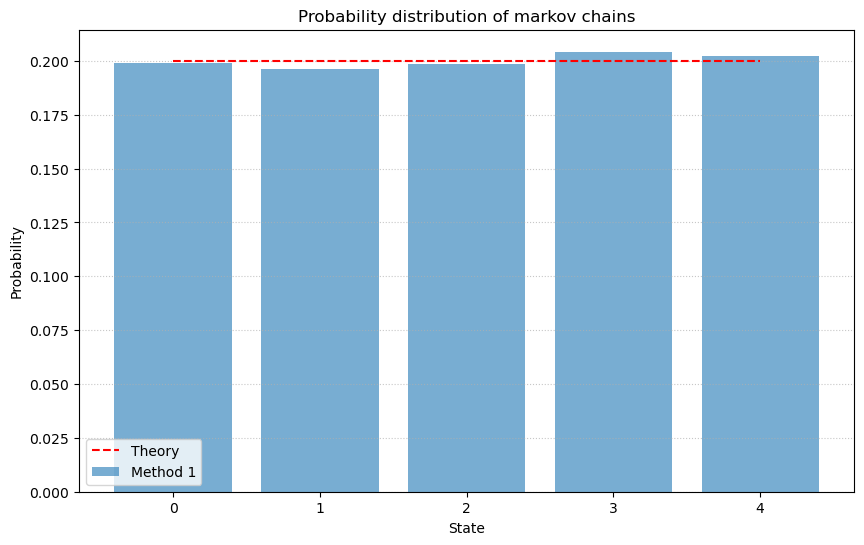

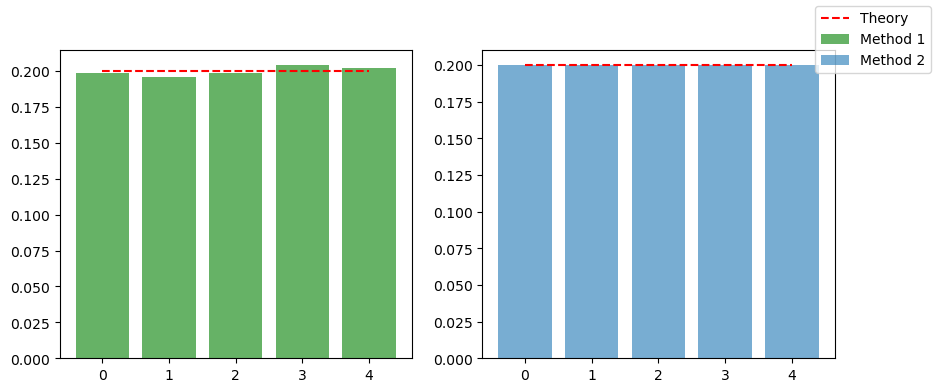

In [20]:
# --- PLOTTING ---
print(f"\nMethod 1: Distribution: {simulated_probs}, Mean: {simulated_mean:.3f}")
print(f"Method 2:   Distribution: {p_t}, Mean: {matrix_mean:.3f}")

plt.figure(figsize=(10, 6))
plt.bar(states, simulated_probs, alpha=0.6, label='Method 1')
plt.step(states, theoretical_probs, where='mid', color='red', label='Theory', linestyle='--')
plt.title("Probability distribution of markov chains")
plt.xlabel("State")
plt.ylabel("Probability")
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(states, simulated_probs, alpha=0.6, color='green', label='Method 1')
axs[0].step(states, theoretical_probs, where='mid', color='red', label='Theory', linestyle='--')
axs[1].bar(states, p_t, alpha=0.6, label='Method 2')
axs[1].step(states, theoretical_probs, where='mid', color='red', linestyle='--')
fig.legend()
plt.show()

> **Why is the final distribution uniform?**
>
> We have symmetric, normalized matrix that fulfill the stationary condition. So when we calculate what is going to be probability that we "land" in each state it is going to be $\frac{1}{5}$.

## Exercise 2: Generate the desired distribution
Use 2 methods: MCMC and the transition matrix
1. Choose desired discrete probability distribution $P$
2. Compute acceptance matrix $$A(i,j) = min(1,\dfrac{P(j)}{P(i)})$$

**Method 1**: Stochastic simulation

3. Choose an initial random state $s_i$
3. Yield a proposed state $s_j$ with probability $p$.
4. Compare $p$ and $A(i \rightarrow j)$:
+ $p<= A(i \rightarrow j)$ : accept $s_j$
+ $p > A(i \rightarrow j)$ : reject, keep same state $s_i$
5. Repeat this procedure and compute equilibrium probability $P^{eq}$.

**Method 2**: Transition matrix

3. Compute transition matrix and use matrix iteration
$$T(i,j) = g(i,j)A(i,j) , i \neq j$$
$$T(i,j) = g(i,j)A(i,j) + \sum_{k \neq i} g(i,k)(1-A(i,k)) , i = j$$
where we choose $g$ is uniform distribution, i.e $g(i \rightarrow j) = 1/N$ for all $i,j$. 

Repeat all the tasks of exercise 2 for the desired continuous distribution.

### Discrete

In [21]:
# --- PARAMETERS ---
P = [0.1, 0.2, 0.4, 0.2, 0.1]
N = len(P)
states = np.arange(N)

A = np.zeros(shape=(N, N))
for i in range(N):
    for j in range(N):
        A[i,j] = min(1, P[j]/P[i])

In [22]:
# --- Method 1 ---
steps = 100000

current_state = np.random.randint(N)
chain_steps = [current_state]

for step in range(steps):
    proposed_state = np.random.choice(a=states)

    p = np.random.rand()

    # reject/accept method
    if  p <= A[current_state, proposed_state]:
        chain_steps.append(proposed_state)
        current_state = proposed_state
    else:
        chain_steps.append(current_state)


distribution = np.bincount(chain_steps)
distribution = distribution/np.sum(distribution)
print(distribution)

[0.10144899 0.20123799 0.39884601 0.19787802 0.10058899]


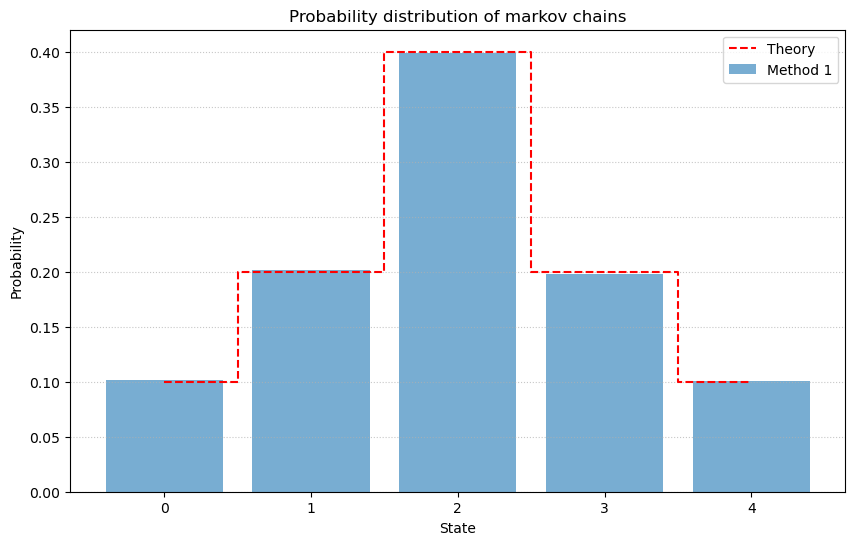

In [23]:
plt.figure(figsize=(10, 6))
plt.bar(np.arange(N), distribution, alpha=0.6, label='Method 1')
plt.step(np.arange(N), P, where='mid', color='red', label='Theory', linestyle='--')
plt.title("Probability distribution of markov chains")
plt.xlabel("State")
plt.ylabel("Probability")
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

In [29]:
# --- METHOD 2 ---

# Cntructing Tranform matrix here
T = np.zeros(shape=(N,N))
g = np.ones(shape=(N, N))/N

for i in range(N):
    for j in range(N):
        if i != j:
            T[i,j] = g[i,j] * A[i,j]
        else:
            T[i,j] = g[i,j] * A[i,j]

            buf = 0
            for k in range(N):
                if k != i:
                    buf += g[i,k] * (1 - A[i,k])

            T[i,j] += buf
print(f"Transition matrix T:\n {T}")

Transition matrix T:
 [[0.2  0.2  0.2  0.2  0.2 ]
 [0.1  0.4  0.2  0.2  0.1 ]
 [0.05 0.1  0.7  0.1  0.05]
 [0.1  0.2  0.2  0.4  0.1 ]
 [0.2  0.2  0.2  0.2  0.2 ]]


In [25]:
steps = 1000
p_t = np.zeros(shape=(N))
p_t[0] = 1
for step in range(steps):
    p_t = p_t @ T

print(p_t)

[0.1 0.2 0.4 0.2 0.1]



Method 1: Distribution: [0.10144899 0.20123799 0.39884601 0.19787802 0.10058899]
Method 2: Distribution: [0.1 0.2 0.4 0.2 0.1]


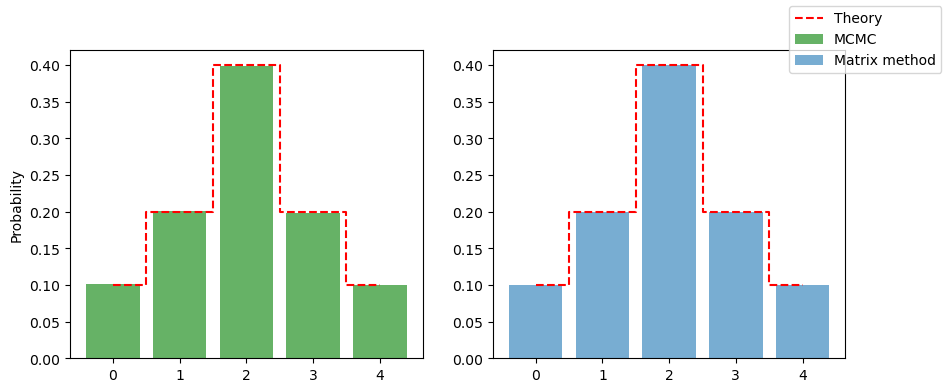

In [26]:
print(f"\nMethod 1: Distribution: {distribution}")
print(f"Method 2: Distribution: {p_t}")

states = np.arange(N)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(states, distribution, alpha=0.6, color='green', label='MCMC')
axs[0].step(states, P, where='mid', color='red', label='Theory', linestyle='--')
axs[0].set_ylabel("Probability")
axs[1].bar(states, p_t, alpha=0.6, label='Matrix method')
axs[1].step(states, P, where='mid', color='red', linestyle='--')
fig.legend()
plt.show()

### Continuous

In [27]:
# --- PARAMETERS ---
sigma = 1.0
steps = 50000
step_size = 1.0

# gausian bell function
def P(x):
    return np.exp(-x**2 / (2 * sigma**2))

# --- METHOD 1 ---
current_point = 0.0
distribution = [current_point]

for step in range(steps):
    candidate_point = current_point + np.random.normal(0, step_size)

    p = np.random.rand()

    if p <= min(1, P(candidate_point)/P(current_point)):
        distribution.append(candidate_point)
        current_point = candidate_point
    else:
        distribution.append(current_point)

distribution = np.array(distribution)

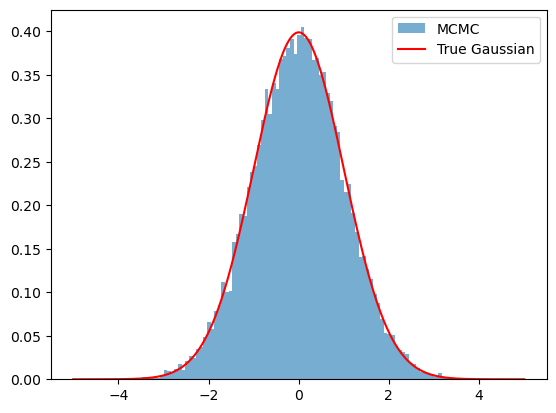

In [28]:
# plotting the histogram of out states (aka distribution)
plt.hist(distribution, bins=100, density=True, alpha=0.6, label="MCMC")

# plotting true gausian
x_vals = np.linspace(-5, 5, 500)
y_vals = P(x_vals)
# nnormalizing the plot
y_vals /= np.trapz(y_vals, x_vals)
plt.plot(x_vals, y_vals, 'r', label="True Gaussian")

plt.legend()
plt.show()

> One thing
>
> I think im not supposed to do the matrix calculation for this method so i assumed that i only need to repeat the first MCMC method